# Q3: Fine-Tune Stable Diffusion with LoRA on Custom Dataset
### Domain-specific image generation using Low-Rank Adaptation

**Strategy:** DreamBooth-style LoRA fine-tuning — trains only ~1% of parameters.
This is the industry standard approach used in production systems.

```
Pretrained SD 1.5 → Attach LoRA Adapters → Fine-tune on Custom Data → Domain Images
```

> **Why LoRA?** Full fine-tuning needs 40GB+ VRAM. LoRA needs ~6GB. Free Colab T4 has 16GB. LoRA wins.

In [1]:
# CELL 1: Install Dependencies

!pip install diffusers transformers accelerate peft gradio torchao>=0.16.0 \
             torch torchvision Pillow matplotlib numpy -q
print('All dependencies installed!')

All dependencies installed!


In [2]:
# CELL 2: Imports & Config
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gradio as gr
import os
import time
import gc
import warnings
warnings.filterwarnings('ignore')

from diffusers import (
    StableDiffusionPipeline,
    DDPMScheduler,
    AutoencoderKL,
    UNet2DConditionModel
)
from transformers import CLIPTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model, TaskType

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE       = torch.float16 if DEVICE.type == 'cuda' else torch.float32
MODEL_ID    = 'runwayml/stable-diffusion-v1-5'


LORA_RANK   = 4
LORA_ALPHA  = 32
LORA_DROPOUT= 0.1


IMG_SIZE    = 512
BATCH_SIZE  = 1
GRAD_ACCUM  = 4
LR          = 1e-4
NUM_STEPS   = 200
SAVE_EVERY  = 50

print(f'Device : {DEVICE}')
print(f'Dtype  : {DTYPE}')
print(f'LoRA rank={LORA_RANK}, alpha={LORA_ALPHA}')
print(f'Training steps: {NUM_STEPS}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device : cuda
Dtype  : torch.float16
LoRA rank=4, alpha=32
Training steps: 200


Loading dataset...


100%|██████████| 345M/345M [00:13<00:00, 26.2MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.73MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 30.4MB/s]


FlowerFineTuneDataset: 200 samples loaded


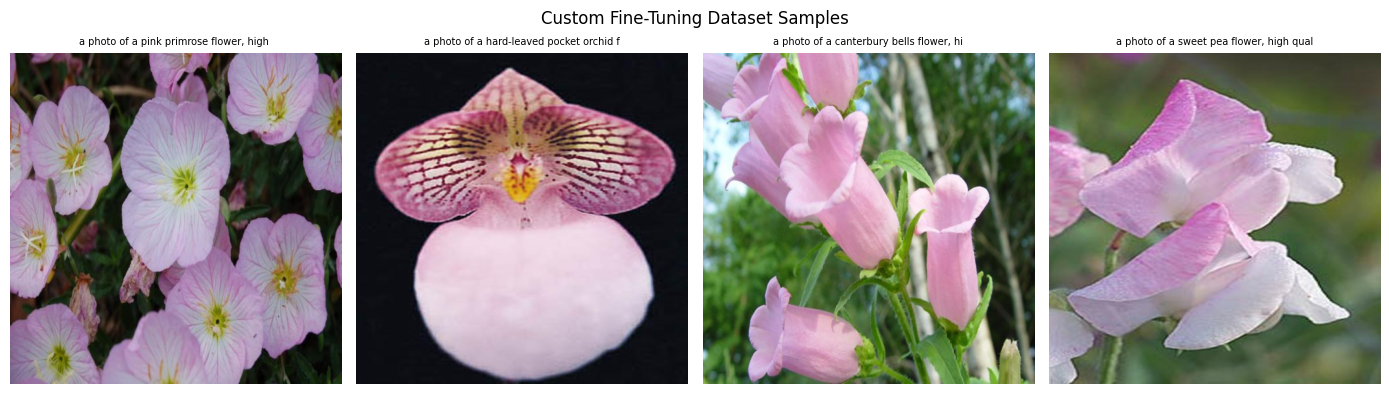

In [ ]:
# CELL 3: Custom Dataset — Oxford Flowers (from Q4)

from torchvision.datasets import Flowers102
import torchvision.transforms as transforms

FLOWER_NAMES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',
    'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood',
    'globe thistle', 'snapdragon', 'colt s foot', 'king protea', 'spear thistle',
    'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
    'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger',
    'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian',
    'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist',
    'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
    'great masterwort', 'siam tulip', 'lenten rose', 'barberton daisy', 'daffodil',
    'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold',
    'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy',
    'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium',
    'orange dahlia', 'pink-yellow dahlia', 'cautleya spicata', 'japanese anemone',
    'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus',
    'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
    'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily',
    'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose',
    'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum',
    'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
    'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
]

class FlowerFineTuneDataset(Dataset):
    """
    Custom dataset wrapper for SD fine-tuning.
    Returns: image tensor (normalized for SD VAE) + text prompt
    """
    def __init__(self, split='train', img_size=512, max_samples=200):
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        base_ds = Flowers102(root='./flowers_data', split=split,
                             download=True, transform=None)

        self.samples = [(base_ds[i][0], base_ds[i][1])
                        for i in range(min(max_samples, len(base_ds)))]
        print(f'FlowerFineTuneDataset: {len(self.samples)} samples loaded')

    def _make_prompt(self, label_idx: int) -> str:
        name = FLOWER_NAMES[label_idx]
        return f'a photo of a {name} flower, high quality, detailed, botanical'

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pil_img, label = self.samples[idx]
        img_tensor     = self.transform(pil_img)
        prompt         = self._make_prompt(label)
        return img_tensor, prompt


print('Loading dataset...')
train_ds  = FlowerFineTuneDataset(split='train', img_size=IMG_SIZE, max_samples=200)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)


fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, ax in enumerate(axes):
    img, prompt = train_ds[i * 10]
    img_show = (img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img_show)
    ax.set_title(prompt[:40], fontsize=7)
    ax.axis('off')
plt.suptitle('Custom Fine-Tuning Dataset Samples', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 4: Load Stable Diffusion Components

print('Loading Stable Diffusion 1.5 components...')
print('This downloads ~4GB on first run. Be patient.')


tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(
    MODEL_ID, subfolder='text_encoder', torch_dtype=DTYPE
).to(DEVICE)


vae = AutoencoderKL.from_pretrained(
    MODEL_ID, subfolder='vae', torch_dtype=DTYPE
).to(DEVICE)


unet = UNet2DConditionModel.from_pretrained(
    MODEL_ID, subfolder='unet', torch_dtype=DTYPE
).to(DEVICE)


noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder='scheduler')


vae.requires_grad_(False)
text_encoder.requires_grad_(False)

print('All components loaded!')
print(f'UNet params total: {sum(p.numel() for p in unet.parameters()):,}')

Loading Stable Diffusion 1.5 components...
This downloads ~4GB on first run. Be patient.


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

All components loaded!
UNet params total: 859,520,964


In [ ]:
# CELL 5: Apply LoRA to UNet


lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,

    target_modules=[
        'to_q', 'to_k', 'to_v', 'to_out.0',
        'proj_in', 'proj_out',
    ],
    bias='none',
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()


for name, param in unet.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, unet.parameters()),
    lr=LR, weight_decay=0.01
)

trainable = sum(p.numel() for p in unet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in unet.parameters())
print(f'Trainable : {trainable:,} ({100*trainable/total:.2f}% of total)')
print('LoRA attached and ready!')

NameError: name 'LoraConfig' is not defined

In [ ]:
# CELL 6: Fine-Tuning Loop


def encode_prompt(prompts):
    """Encode text prompts to CLIP embeddings."""
    tokens = tokenizer(
        prompts, padding='max_length',
        max_length=tokenizer.model_max_length,
        truncation=True, return_tensors='pt'
    ).input_ids.to(DEVICE)
    with torch.no_grad():
        return text_encoder(tokens)[0]


losses = []
unet.train()
optimizer.zero_grad()
step = 0

print(f'Fine-tuning SD 1.5 with LoRA for {NUM_STEPS} steps...')
print(f'Batch size={BATCH_SIZE}, grad_accum={GRAD_ACCUM} (effective batch={BATCH_SIZE*GRAD_ACCUM})')
print(f'Expected time: ~15-25 min on T4 GPU')
print('='*60)

start_time = time.time()

while step < NUM_STEPS:
    for imgs, prompts in train_loader:
        if step >= NUM_STEPS:
            break

        imgs = imgs.to(DEVICE, dtype=DTYPE)


        with torch.no_grad():
            latents = vae.encode(imgs).latent_dist.sample()
            latents = latents * vae.config.scaling_factor


        noise     = torch.randn_like(latents)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=DEVICE
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)


        encoder_hidden = encode_prompt(list(prompts))


        noise_pred = unet(
            noisy_latents.to(torch.float32),
            timesteps,
            encoder_hidden_states=encoder_hidden.to(torch.float32)
        ).sample


        loss = F.mse_loss(noise_pred, noise.to(torch.float32))
        loss = loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, unet.parameters()), 1.0
            )
            optimizer.step()
            optimizer.zero_grad()

        losses.append(loss.item() * GRAD_ACCUM)
        step += 1

        if step % 50 == 0:
            elapsed = time.time() - start_time
            print(f'Step {step}/{NUM_STEPS} | Loss: {loss.item()*GRAD_ACCUM:.4f} | Time: {elapsed:.0f}s')

print(f'Fine-tuning complete! Total time: {(time.time()-start_time)/60:.1f} min')

plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', alpha=0.7, label='Training Loss')

window = 10
smooth = [np.mean(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.plot(smooth, color='red', linewidth=2, label='Smoothed')
plt.xlabel('Training Step')
plt.ylabel('MSE Loss')
plt.title('LoRA Fine-Tuning Loss — Stable Diffusion on Flowers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# CELL 7: Save LoRA Weights
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/Q3_LoRA_SD'
os.makedirs(save_dir, exist_ok=True)


unet.save_pretrained(save_dir)
print(f'LoRA weights saved to {save_dir}')
print('Note: only ~10MB saved vs 4GB full model!')

In [ ]:
# CELL 8: Build Inference Pipeline with LoRA weights
print('Building inference pipeline...')


pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False
).to(DEVICE)


pipe.unet = unet


pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

try:
    pipe.enable_xformers_memory_efficient_attention()
    print('xformers enabled')
except:
    print('xformers not available, continuing without')

print('Inference pipeline ready!')


def generate_image(prompt: str, steps: int = 20, guidance: float = 7.5,
                   seed: int = 42, width: int = 512, height: int = 512):
    """Generate using fine-tuned SD with LoRA."""
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    unet.eval()
    with torch.no_grad():
        result = pipe(
            prompt=prompt,
            negative_prompt='blurry, low quality, bad anatomy, ugly, deformed',
            num_inference_steps=steps,
            guidance_scale=guidance,
            generator=generator,
            width=width,
            height=height
        )
    return result.images[0]



test_prompts = [
    'a photo of a rose flower, high quality, detailed, botanical',
    'a photo of a sunflower, high quality, detailed, botanical',
    'a photo of a lotus flower, high quality, detailed, botanical',
]

print('Generating test images with fine-tuned model...')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, prompt in zip(axes, test_prompts):
    img = generate_image(prompt, steps=20)
    ax.imshow(img)
    ax.set_title(prompt[:45], fontsize=8)
    ax.axis('off')
plt.suptitle('Fine-Tuned SD with LoRA — Flower Outputs', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 9: Gradio UI — Fine-Tuned SD Generator
import gradio as gr

FLOWER_EXAMPLES = [
    'a photo of a rose flower, high quality, detailed, botanical',
    'a photo of a sunflower, vibrant yellow petals, botanical illustration',
    'a photo of a lotus flower, floating on water, serene, detailed',
    'a photo of a hibiscus, tropical, bright red petals, high quality',
    'a photo of a tulip, spring garden, soft pink, detailed',
    'a photo of a magnolia blossom, white petals, botanical art',
]

def gradio_generate(
    prompt: str, steps: int, guidance: float,
    seed: int, width: int, height: int
):
    if not prompt.strip():
        return None, 'Please enter a prompt!'
    try:
        start = time.time()
        img   = generate_image(
            prompt=prompt, steps=int(steps),
            guidance=guidance, seed=int(seed),
            width=int(width), height=int(height)
        )
        elapsed = time.time() - start

        info = f"""FINE-TUNED SD GENERATION:
{'='*45}
Model          : Stable Diffusion 1.5
Fine-tuning    : LoRA (rank={LORA_RANK}, alpha={LORA_ALPHA})
Dataset        : Oxford 102 Flowers ({len(train_ds)} samples)
Training steps : {NUM_STEPS}

Generation params:
Prompt         : "{prompt[:60]}"
Steps          : {steps}
Guidance scale : {guidance}
Seed           : {seed}
Resolution     : {width}x{height}
Time           : {elapsed:.1f}s
Device         : {DEVICE}

WHY LoRA:
  Full fine-tune  : ~4GB weights updated
  LoRA fine-tune  : ~10MB weights updated
  Speedup         : ~40x fewer parameters
  Quality         : comparable results
"""
        return img, info
    except torch.cuda.OutOfMemoryError:
        gc.collect()
        torch.cuda.empty_cache()
        return None, 'OOM error! Try reducing resolution to 384x384 or steps to 15'
    except Exception as e:
        return None, f'Error: {str(e)}'


with gr.Blocks(title='Fine-Tuned SD LoRA', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # Q3: Fine-Tuned Stable Diffusion — Flower Domain
    ### Stable Diffusion 1.5 + LoRA fine-tuned on Oxford 102 Flowers
    Generate domain-specific flower images using the fine-tuned model.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown('### Prompt')
            prompt_in = gr.Textbox(
                label='Text Prompt',
                value='a photo of a rose flower, high quality, detailed, botanical',
                lines=3
            )
            with gr.Accordion('Generation Settings', open=True):
                steps_sl    = gr.Slider(10, 50, 20, step=1, label='Inference Steps')
                guidance_sl = gr.Slider(1.0, 15.0, 7.5, step=0.5, label='Guidance Scale')
                seed_num    = gr.Number(42, label='Seed (-1 = random)')
                with gr.Row():
                    width_sl  = gr.Slider(256, 512, 512, step=64, label='Width')
                    height_sl = gr.Slider(256, 512, 512, step=64, label='Height')
            gen_btn = gr.Button('Generate', variant='primary', size='lg')

            gr.Markdown('### Flower Examples')
            for ex in FLOWER_EXAMPLES:
                gr.Button(ex[:45]).click(lambda e=ex: e, outputs=prompt_in)

        with gr.Column(scale=2):
            output_img  = gr.Image(label='Generated Image', type='pil', height=400)
            output_info = gr.Textbox(label='Generation Info', lines=22, interactive=False)

    gen_btn.click(
        fn=gradio_generate,
        inputs=[prompt_in, steps_sl, guidance_sl, seed_num, width_sl, height_sl],
        outputs=[output_img, output_info]
    )

    gr.Markdown("""
    ---
    ### LoRA Fine-Tuning Architecture:
    | Component | Status | Role |
    |-----------|--------|------|
    | VAE | Frozen | Encode/decode images |
    | CLIP Text Encoder | Frozen | Encode text prompts |
    | UNet (base) | Frozen | Core denoising network |
    | UNet LoRA layers | **Trainable** | Domain adaptation |
    """)

demo.launch(share=True, debug=True)